# Mini BERT 만들기

- vocab_size: 8000
- 전체 파라미터: ~1M
- 학습: 10 Epoch
- 추가: MLM / NSP 인퍼런스

## 0. 라이브러리 버전 확인

In [1]:
import torch
import numpy
import pandas
import matplotlib
import json
import re
print('torch    :', torch.__version__)
print('numpy    :', numpy.__version__)
print('pandas   :', pandas.__version__)
print('matplotlib:', matplotlib.__version__)

torch    : 2.7.1+cu118
numpy    : 2.2.6
pandas   : 2.3.0
matplotlib: 3.10.3


In [2]:
import os

# 경로 설정
data_dir          = '/home/jovyan/data'
work_dir          = '/home/jovyan/work'

os.makedirs(work_dir, exist_ok=True)

corpus_file        = f'{data_dir}/kowiki.txt'
pretrain_json_path = f'{work_dir}/bert_pre_train_8000.json'

print("data_dir   :", data_dir)
print("work_dir   :", work_dir)
print("corpus_file 존재:", os.path.exists(corpus_file))
print("ko_8000.model 존재:", os.path.exists(f'{data_dir}/ko_8000.model'))

data_dir   : /home/jovyan/data
work_dir   : /home/jovyan/work
corpus_file 존재: True
ko_8000.model 존재: True


## 1. Imports & 기본 설정

In [3]:
from __future__ import absolute_import, division, print_function, unicode_literals
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os, re, math, copy, json, random, collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm
from datetime import datetime

random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

print(torch.__version__)
print('완료')

2.7.1+cu118
완료


## 2. Tokenizer 준비

vocab_size=8000인 SentencePiece BPE 모델 생성

특수 토큰 7개 (ID 0~6):
- 0: [PAD], 1: [UNK], 2: [BOS], 3: [EOS], 4: [SEP], 5: [CLS], 6: [MASK]

In [4]:
data_dir = 'data'
corpus_file = f'{data_dir}/kowiki.txt'

# ── 직접 학습하려면 아래 주석 해제 (약 15~30분 소요) ──
# spm.SentencePieceTrainer.train(
#     f'--input={corpus_file}'
#     f' --model_prefix={prefix}'
#     f' --vocab_size={vocab_size + 7}'   # 특수 토큰 7개 포함
#     f' --model_type=bpe'
#     f' --max_sentence_length=999999'
#     f' --pad_id=0 --pad_piece=[PAD]'
#     f' --unk_id=1 --unk_piece=[UNK]'
#     f' --bos_id=2 --bos_piece=[BOS]'
#     f' --eos_id=3 --eos_piece=[EOS]'
#     f' --user_defined_symbols=[SEP],[CLS],[MASK]'
# )

# 미리 학습된 모델 로드
vocab = spm.SentencePieceProcessor()
vocab.load('/home/jovyan/data/ko_8000.model')  # 절대경로로 직접 지정
print(f'vocab size: {len(vocab)}')

# 특수 토큰 7개 제외한 일반 vocab 목록 (랜덤 마스킹용)
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))
print(f'vocab_list size: {len(vocab_list)}')
print('완료')

vocab size: 8007
vocab_list size: 8000
완료


In [5]:
# 토크나이저 동작 확인
string_a = '추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아'
string_b = '손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔'
tokens_org = ['[CLS]'] + vocab.encode_as_pieces(string_a) + ['[SEP]'] + vocab.encode_as_pieces(string_b) + ['[SEP]']
print('tokens_org:', tokens_org)
print('완료')

tokens_org: ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']
완료


## 3. 데이터 전처리

### (1) MASK 생성

- 전체 토큰의 **15%** 마스킹
- 마스킹 토큰 중: **80%** → `[MASK]`, **10%** → 랜덤 토큰, **10%** → 원래 토큰
- **띄어쓰기 단위(word-level)** 로 마스킹 (subword 일관성)

In [6]:
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    MLM 마스크 생성
    :param tokens: [CLS]+A+[SEP]+B+[SEP] 형태 토큰 리스트
    :param mask_cnt: 마스킹할 토큰 수 (전체의 15%)
    :param vocab_list: 랜덤 교체용 어휘 리스트
    :return tokens: 마스킹 적용된 토큰 리스트
    :return mask_idx: 마스킹된 위치 인덱스
    :return mask_label: 원래 토큰(정답)
    """
    # ▁(U+2581): SentencePiece에서 단어 시작 표시
    # 단어 단위로 묶어야 subword 중간만 마스킹되는 문제 방지
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == '[CLS]' or token == '[SEP]':
            continue
        if 0 < len(cand_idx) and not token.startswith(u'\u2581'):
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])

    random.shuffle(cand_idx)

    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        # 같은 단어의 subword는 동일한 처리 적용 (dice 한 번만 뽑음)
        dice = random.random()
        for index in index_set:
            if dice < 0.8:
                masked_token = '[MASK]'
            elif dice < 0.9:
                masked_token = tokens[index]
            else:
                masked_token = random.choice(vocab_list)
            mask_lms.append({'index': index, 'label': tokens[index]})
            tokens[index] = masked_token

    mask_lms = sorted(mask_lms, key=lambda x: x['index'])
    mask_idx   = [p['index'] for p in mask_lms]
    mask_label = [p['label'] for p in mask_lms]
    return tokens, mask_idx, mask_label

print('완료')

완료


In [7]:
# 마스킹 동작 확인
tokens = copy.deepcopy(tokens_org)
mask_cnt = int((len(tokens_org) - 3) * 0.15)
tokens, mask_idx, mask_label = create_pretrain_mask(tokens, mask_cnt, vocab_list)
print('tokens_org :', tokens_org)
print('tokens     :', tokens)
print('mask_idx   :', mask_idx)
print('mask_label :', mask_label)

tokens_org : ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']
tokens     : ['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '[MASK]', '[MASK]', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님', '이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물이', '▁흘', '러', '▁컬', '컬', '한', '▁목', '에', '▁모', '주', '[MASK]', '[MASK]', '[MASK]', '▁적', '셔', '[SEP]']
mask_idx   : [7, 8, 43, 44, 45]
mask_label : ['▁내', '리는', '▁한', '잔', '을']


### (2) NSP pair 생성

- 두 문장을 짝지어 **50% TRUE / 50% FALSE** 생성
- Segment: 문장A → 0, 문장B → 1
- 구조: `[CLS] + A + [SEP] + B + [SEP]`

In [8]:
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    두 문장 길이 합을 max_seq 이하로 조정
    tokens_a: 앞에서 제거 (뒷부분 = B와의 연결 맥락 보존)
    tokens_b: 뒤에서 제거 (앞부분 = A와의 연결 시작 보존)
    """
    while True:
        if len(tokens_a) + len(tokens_b) <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()


def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    하나의 문서로부터 MLM + NSP pretrain 학습 데이터 생성
    instance 구조:
      tokens    : 마스킹 적용된 토큰 리스트
      segment   : 문장A=0, 문장B=1 segment 리스트
      is_next   : NSP 정답 (1=TRUE, 0=FALSE)
      mask_idx  : 마스킹된 위치 인덱스
      mask_label: 마스킹 전 원래 토큰(정답)
    """
    max_seq = n_seq - 3  # [CLS], [SEP], [SEP] 제외
    instances = []
    current_chunk = []
    current_length = 0

    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            a_end = random.randrange(1, len(current_chunk)) if 1 < len(current_chunk) else 1
            tokens_a = [t for j in range(a_end) for t in current_chunk[j]]
            tokens_b = [t for j in range(a_end, len(current_chunk)) for t in current_chunk[j]]

            # NSP: 50% 확률로 swap → FALSE 쌍
            if random.random() < 0.5:
                is_next = 0
                tokens_a, tokens_b = tokens_b, tokens_a
            else:
                is_next = 1

            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)

            tokens = ['[CLS]'] + tokens_a + ['[SEP]'] + tokens_b + ['[SEP]']
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

            # MLM 마스킹 적용
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list
            )
            instances.append({
                'tokens'    : tokens,
                'segment'   : segment,
                'is_next'   : is_next,
                'mask_idx'  : mask_idx,
                'mask_label': mask_label
            })
            current_chunk = []
            current_length = 0
    return instances

print('완료')

완료


### (3) 데이터셋 완성

- kowiki.txt 전체를 JSONL로 저장
- `np.memmap`으로 메모리 효율적 로딩

In [9]:
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """pretrain 데이터 생성 및 JSONL 저장"""
    # 특수 토큰 7개 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))

    def save_pretrain_instances(out_f, doc):
        instances = create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list)
        for instance in instances:
            out_f.write(json.dumps(instance, ensure_ascii=False))
            out_f.write('\n')

    # 전체 라인 수 확인 (tqdm 진행률용)
    line_cnt = 0
    with open(in_file, 'r') as f:
        for _ in f:
            line_cnt += 1

    with open(in_file, 'r') as in_f, open(out_file, 'w') as out_f:
        doc = []
        for line in tqdm(in_f, total=line_cnt):
            line = line.strip()
            if line == '':  # 빈 줄 = 단락 경계
                if 0 < len(doc):
                    save_pretrain_instances(out_f, doc)
                    doc = []
            else:
                pieces = vocab.encode_as_pieces(line)
                if 0 < len(pieces):
                    doc.append(pieces)
        if 0 < len(doc):  # 마지막 미처리 doc
            save_pretrain_instances(out_f, doc)

print('완료')

완료


In [10]:
# pretrain 데이터 생성 (n_seq=128)
pretrain_json_path = '/home/jovyan/work/bert_pre_train_8000.json'
corpus_file = '/home/jovyan/data/kowiki.txt'
os.makedirs('/home/jovyan/work', exist_ok=True)
make_pretrain_data(vocab, corpus_file, pretrain_json_path, n_seq=128)
print('데이터 생성 완료')

  0%|          | 0/3957761 [00:00<?, ?it/s]

데이터 생성 완료


In [11]:
# 생성된 인스턴스 수 확인
total = 0
with open(pretrain_json_path, 'r') as f:
    for _ in f:
        total += 1
print(f'총 instance 수: {total:,}')

총 instance 수: 918,189


In [12]:
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    JSONL → np.memmap 변환 로드
    :param count: 로드할 데이터 수 제한 (None=전체)
    :return (enc_tokens, segments), (labels_nsp, labels_mlm)
    """
    total = 0
    with open(filename, 'r') as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break

    enc_tokens = np.memmap(f'{work_dir}/enc_tokens.memmap',  mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments   = np.memmap(f'{work_dir}/segments.memmap',    mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(f'{work_dir}/labels_nsp.memmap',  mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(f'{work_dir}/labels_mlm.memmap',  mode='w+', dtype=np.int32, shape=(total, n_seq))

    with open(filename, 'r') as f:
        for i, line in enumerate(tqdm(f, total=total)):
            if total <= i:
                break
            data = json.loads(line)

            enc_token = [vocab.piece_to_id(p) for p in data['tokens']]
            enc_token += [0] * (n_seq - len(enc_token))  # [PAD]=0 패딩

            segment = data['segment']
            segment += [0] * (n_seq - len(segment))

            mask_idx   = np.array(data['mask_idx'],   dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data['mask_label']], dtype=np.int32)
            label_mlm  = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label  # 마스킹 위치에만 정답 ID 삽입

            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq
            enc_tokens[i] = enc_token
            segments[i]   = segment
            labels_nsp[i] = data['is_next']
            labels_mlm[i] = label_mlm

    return (enc_tokens, segments), (labels_nsp, labels_mlm)

print('완료')

완료


In [13]:
# 128,000건 로딩
n_seq = 128
pre_train_inputs, pre_train_labels = load_pre_train_data(vocab, pretrain_json_path, n_seq, count=128000)
print(f'enc_tokens shape: {pre_train_inputs[0].shape}')
print(f'segments   shape: {pre_train_inputs[1].shape}')
print(f'labels_nsp shape: {pre_train_labels[0].shape}')
print(f'labels_mlm shape: {pre_train_labels[1].shape}')
print('로딩 완료')

  0%|          | 0/128000 [00:00<?, ?it/s]

enc_tokens shape: (128000, 128)
segments   shape: (128000, 128)
labels_nsp shape: (128000,)
labels_mlm shape: (128000, 128)
로딩 완료


## 4. BERT 모델 구현

### 유틸리티 함수

In [14]:
def get_pad_mask(tokens, i_pad=0):
    """PAD 위치 마스크 (PAD=1, 나머지=0)"""
    mask = (tokens == i_pad).float().unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """미래 토큰 + PAD 마스크 (GPT 계열용)"""
    n_seq = tokens.size(1)
    ahead_mask = (1 - torch.tril(torch.ones((n_seq, n_seq)))).unsqueeze(0)
    pad_mask   = get_pad_mask(tokens, i_pad)
    return torch.maximum(ahead_mask, pad_mask)

def gelu(x):
    """BERT 원논문 GELU 구현"""
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

def kernel_initializer(stddev=0.02):
    return torch.nn.init.trunc_normal_

def bias_initializer():
    return torch.zeros_

class Config(dict):
    """JSON config를 속성처럼 접근 가능하게 래핑"""
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            return Config(json.loads(f.read()))

print('완료')

완료


### Embedding 레이어

In [15]:
class SharedEmbedding(nn.Module):
    """
    Weight Shared Embedding
    - mode='embedding': 토큰 ID → 벡터 (입력단)
    - mode='linear'   : 벡터 → vocab logit (출력단, 같은 가중치 공유)
    가중치 공유로 파라미터 절약 + 학습 안정성 향상
    """
    def __init__(self, config):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)

    def forward(self, inputs, mode='embedding'):
        if mode == 'embedding':
            return self._embedding(inputs)
        elif mode == 'linear':
            return self._linear(inputs)
        raise ValueError(f'mode {mode} is not valid.')

    def _embedding(self, inputs):
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]

    def _linear(self, inputs):
        n_batch, n_seq, _ = inputs.shape
        outputs = torch.matmul(inputs.view(-1, self.d_model), self.shared_weights.T)
        return outputs.view(n_batch, n_seq, self.n_vocab)


class PositionEmbedding(nn.Module):
    """
    Learned Position Embedding (BERT 방식)
    sinusoidal 고정 방식이 아닌 학습 가능한 파라미터
    최대 n_seq(512) 위치까지 지원
    """
    def __init__(self, config):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)

    def forward(self, inputs):
        # cumsum으로 배치 크기 무관하게 [0,1,2,...,n_seq-1] 생성
        position = (torch.cumsum(torch.ones_like(inputs), dim=1) - 1).long()
        return self.embedding(position)

print('완료')

완료


### Transformer Encoder 레이어

In [16]:
class ScaleDotProductAttention(nn.Module):
    """Scaled Dot-Product Attention"""
    def __init__(self):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        scale      = torch.sqrt(torch.tensor(K.shape[-1], dtype=torch.float32))
        attn_score = torch.matmul(Q, K.transpose(-2, -1)) / scale
        attn_score = attn_score - (attn_mask * 1e9)  # 마스크 위치 → -∞ (softmax 후 0)
        attn_prob  = F.softmax(attn_score, dim=-1)
        return torch.matmul(attn_prob, V)


class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention
    d_model → n_head 개로 분할 → 각각 attention → 다시 합산
    """
    def __init__(self, config):
        super().__init__()
        self.n_head = config.n_head
        self.d_head = config.d_head
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.attention = ScaleDotProductAttention()
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)

    def forward(self, Q, K, V, attn_mask):
        bs = Q.shape[0]
        Q_m = self.W_Q(Q).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(bs, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask.unsqueeze(1))
        attn_out = attn_out.transpose(1, 2).contiguous().view(bs, -1, self.n_head * self.d_head)
        return self.W_O(attn_out)


class PositionWiseFeedForward(nn.Module):
    """FFN: d_model → d_ff → d_model (GELU 활성화)"""
    def __init__(self, config):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()

    def forward(self, inputs):
        return self.W_2(self.gelu(self.W_1(inputs)))


class EncoderLayer(nn.Module):
    """
    Transformer Encoder Layer
    Self-Attention → Add & Norm → FFN → Add & Norm
    """
    def __init__(self, config):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1   = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.ffn     = PositionWiseFeedForward(config)
        self.norm2   = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, enc_embed, self_mask):
        attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(attn_val))
        ffn_val   = self.ffn(norm1_val)
        return self.norm2(norm1_val + self.dropout(ffn_val))

print('완료')

완료


### BERT & PreTrain 모델

In [17]:
class BERT(nn.Module):
    """
    BERT 모델
    3종 임베딩(Token + Position + Segment) 합산 후 Encoder 통과
    """
    def __init__(self, config):
        super().__init__()
        self.i_pad    = config.i_pad
        self.embedding = SharedEmbedding(config)
        self.position  = PositionEmbedding(config)
        self.segment   = nn.Embedding(2, config.d_model)  # A=0, B=1
        self.norm      = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        self.encoder_layers = nn.ModuleList([EncoderLayer(config) for _ in range(config.n_layer)])
        self.dropout   = nn.Dropout(config.dropout)

    def forward(self, enc_tokens, segments):
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        enc_out = self.dropout(self.get_embedding(enc_tokens, segments))
        for layer in self.encoder_layers:
            enc_out = layer(enc_out, enc_self_mask)
        logits_cls = enc_out[:, 0]                          # [CLS] 토큰 → NSP
        logits_lm  = self.embedding(enc_out, mode='linear') # 전체 → MLM
        return logits_cls, logits_lm

    def get_embedding(self, tokens, segments):
        """Token + Position + Segment 임베딩 합산 후 LayerNorm"""
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        return self.norm(embed)


class PooledOutput(nn.Module):
    """NSP Head: [CLS] 벡터 → 2클래스 (TRUE/FALSE)"""
    def __init__(self, config, n_output):
        super().__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)

    def forward(self, inputs):
        return self.dense2(F.tanh(self.dense1(inputs)))


class PreTrainModel(nn.Module):
    """BERT Pretrain 모델 (MLM + NSP 동시 학습)"""
    def __init__(self, config):
        super().__init__()
        self.bert         = BERT(config)
        self.pooled_output = PooledOutput(config, 2)

    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments   = segments.long()
        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        logits_nsp = self.pooled_output(logits_cls)
        return logits_nsp, logits_lm


def build_model_pre_train(config):
    return PreTrainModel(config)

print('완료')

완료


In [18]:
# ── Mini BERT Config (~1M 파라미터) ──
# 파라미터 추정:
#   Embedding : (8007 * 64) + (128 * 64) + (2 * 64) ≈ 520K
#   Encoder x4: 각 레이어 ~120K → 4 * 120K ≈ 480K
#   NSP Head  : 64*64 + 64*2   ≈ 4K
#   합계: ~1.0M
config = Config({
    'd_model'           : 64,
    'n_head'            : 4,
    'd_head'            : 16,
    'dropout'           : 0.1,
    'd_ff'              : 256,
    'layernorm_epsilon' : 1e-12,
    'n_layer'           : 4,
    'n_seq'             : 128,
    'n_vocab'           : len(vocab),  # 자동으로 32007 읽어옴
    'i_pad'             : 0
})

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

pre_train_model = build_model_pre_train(config).to(device)

# 파라미터 수 확인
total_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)
print(f'총 학습 파라미터 수: {total_params:,} ({total_params/1e6:.2f}M)')
print('완료')

device: cuda
총 학습 파라미터 수: 725,120 (0.73M)
완료


## 5. Pretrain 진행

### Loss / Accuracy 함수 & LR 스케줄러

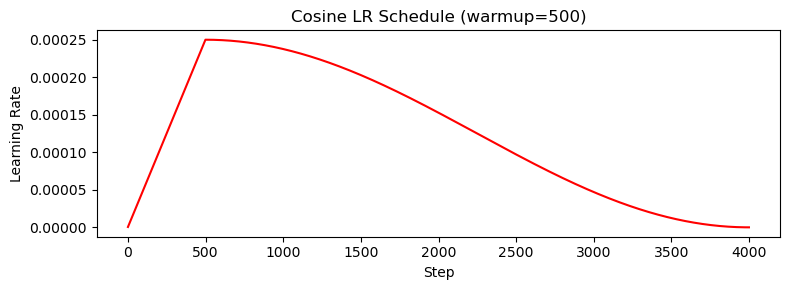

완료


In [19]:
def lm_loss(y_true, y_pred):
    """
    MLM Loss (PAD 위치 제외)
    PAD(0)는 마스킹 대상이 아니므로 loss 계산에서 제외
    × 20: MLM loss 스케일이 NSP보다 작아지는 경향 보정
    """
    loss = F.cross_entropy(y_pred.view(-1, y_pred.size(-1)), y_true.view(-1), reduction='none')
    mask = (y_true != 0).float()
    loss = (loss * mask.view(-1)).mean()
    return loss * 20


def lm_acc(y_true, y_pred):
    """
    MLM Accuracy (PAD 위치 제외)
    """
    y_pred_class = torch.argmax(y_pred, dim=-1).float()
    mask    = (y_true != 0).float()
    matches = (y_true == y_pred_class).float() * mask
    return matches.sum() / mask.sum().clamp(min=1)


class CosineSchedule:
    """
    Warmup + Cosine Decay LR 스케줄러
    - warmup: 0 → max_lr 선형 증가 (초반 불안정 방지)
    - decay : max_lr → 0 cosine 감소 (세밀한 수렴)
    """
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer    = optimizer
        self.train_steps  = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr       = max_lr
        self.step_num     = 0

    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            return (self.step_num / self.warmup_steps) * self.max_lr
        progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
        return 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))

    def step(self):
        self.step_num += 1
        return self.get_lr()


# LR 스케줄 시각화
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = [test_schedule.step() for _ in range(4000)]
plt.figure(figsize=(8, 3))
plt.plot(lrs, 'r-')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Cosine LR Schedule (warmup=500)')
plt.tight_layout()
plt.show()
print('완료')

### 10 Epoch 학습

In [20]:
epochs     = 10
batch_size = 64

# 데이터 → GPU 텐서 변환
pre_train_inputs_t = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels_t = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset    = TensorDataset(*pre_train_inputs_t, *pre_train_labels_t)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

train_steps = math.ceil(len(pre_train_inputs_t[0]) / batch_size) * epochs
print(f'train_steps: {train_steps:,}')

lr_scheduler = CosineSchedule(
    train_steps  = train_steps,
    warmup_steps = max(100, train_steps // 10),
    max_lr       = 2.5e-4
)
optimizer    = optim.Adam(pre_train_model.parameters(), lr=1e-4)
loss_fn_nsp  = nn.CrossEntropyLoss()

history = {'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

for epoch in range(epochs):
    pre_train_model.train()
    total_nsp_loss = total_mlm_loss = total_nsp_acc = total_mlm_acc = 0.0

    for batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{epochs}'):
        enc_tokens_b, segments_b, labels_nsp_b, labels_mlm_b = batch
        labels_nsp_b = labels_nsp_b.long()
        labels_mlm_b = labels_mlm_b.clamp(0, config.n_vocab - 1).long()

        optimizer.zero_grad()
        logits_nsp, logits_lm = pre_train_model(enc_tokens_b, segments_b)

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_b)
        loss_mlm = lm_loss(labels_mlm_b, logits_lm)   # PAD 제외 + ×20 스케일링
        (loss_nsp + loss_mlm).backward()

        # CosineSchedule로 LR 업데이트
        lr = lr_scheduler.step()
        for pg in optimizer.param_groups:
            pg['lr'] = lr
        optimizer.step()

        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()
        total_nsp_acc  += (logits_nsp.argmax(dim=-1) == labels_nsp_b).float().mean().item()
        total_mlm_acc  += lm_acc(labels_mlm_b, logits_lm).item()

    n = len(train_dataloader)
    history['nsp_loss'].append(total_nsp_loss / n)
    history['mlm_loss'].append(total_mlm_loss / n)
    history['nsp_acc'].append(total_nsp_acc   / n)
    history['mlm_acc'].append(total_mlm_acc   / n)

    print(f'[Epoch {epoch+1:2d}/{epochs}] '
          f'NSP loss: {history["nsp_loss"][-1]:.4f} | '
          f'MLM loss: {history["mlm_loss"][-1]:.4f} | '
          f'NSP acc: {history["nsp_acc"][-1]:.4f} | '
          f'MLM acc: {history["mlm_acc"][-1]:.4f}')

    # epoch별 모델 저장
    torch.save(pre_train_model.state_dict(), f'{work_dir}/mini_bert_epoch_{epoch+1:02d}.pt')

print('학습 완료!')

train_steps: 20,000


Epoch 1/10:   0%|          | 0/2000 [00:00<?, ?it/s]

[Epoch  1/10] NSP loss: 0.6308 | MLM loss: 20.4735 | NSP acc: 0.5914 | MLM acc: 0.0256


Epoch 2/10:   0%|          | 0/2000 [00:00<?, ?it/s]

[Epoch  2/10] NSP loss: 0.5931 | MLM loss: 19.3420 | NSP acc: 0.5936 | MLM acc: 0.0291


...

[Epoch  8/10] NSP loss: 0.5644 | MLM loss: 17.5447 | NSP acc: 0.6242 | MLM acc: 0.0701


Epoch 9/10:   0%|          | 0/2000 [00:00<?, ?it/s]

[Epoch  9/10] NSP loss: 0.5633 | MLM loss: 17.4808 | NSP acc: 0.6255 | MLM acc: 0.0724


Epoch 10/10:   0%|          | 0/2000 [00:00<?, ?it/s]

[Epoch 10/10] NSP loss: 0.5630 | MLM loss: 17.4592 | NSP acc: 0.6273 | MLM acc: 0.0730
학습 완료!


## 6. 학습 결과 시각화

/tmp/ipykernel_215/3687528008.py:22: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/3687528008.py:22: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/3687528008.py:22: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/3687528008.py:22: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/3687528008.py:23: UserWarning: Glyph 54617 (\N{HANGUL SYLLABLE HAG}) missing from font(s) DejaVu Sans.
  plt.savefig('work/mini_bert_training_result.png', dpi=150)
/tmp/ipykernel_215/3687528008.py:23: UserWarning: Glyph 49845 (\N{HANGUL SYLLABLE SEUB}) missing from font(s) DejaVu Sans.
  plt.savefig('work/mini_bert_training_result.png', dpi=150)
/tmp/ipykernel_215/3687528008.py:23: UserWarning: Glyph 44

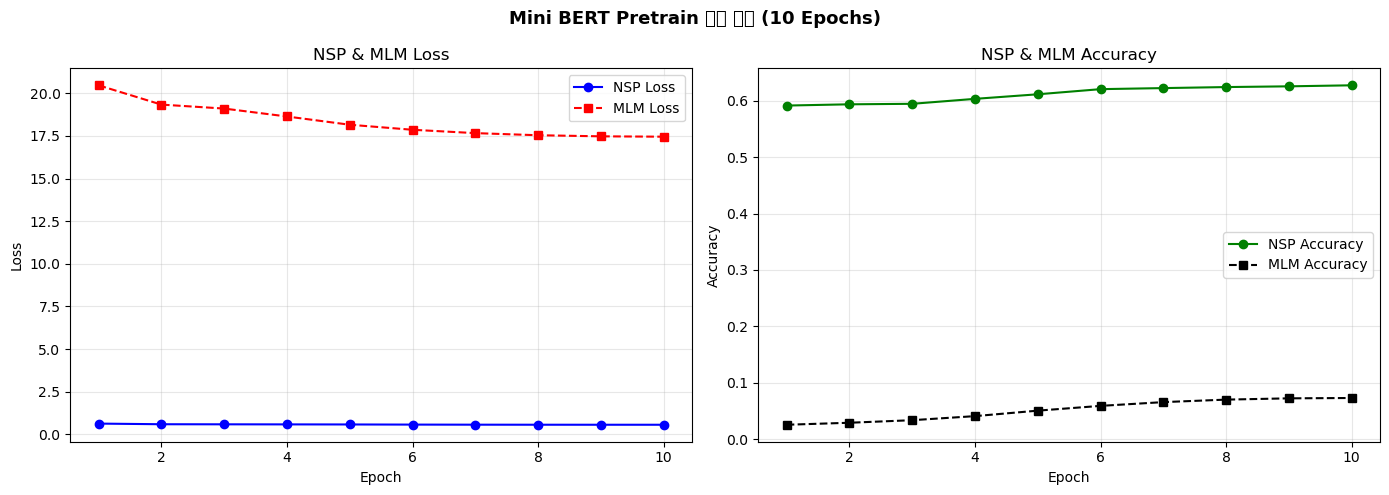

완료


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(range(1, epochs+1), history['nsp_loss'], 'b-o', label='NSP Loss')
ax.plot(range(1, epochs+1), history['mlm_loss'], 'r--s', label='MLM Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('NSP & MLM Loss')
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(1, epochs+1), history['nsp_acc'], 'g-o', label='NSP Accuracy')
ax.plot(range(1, epochs+1), history['mlm_acc'], 'k--s', label='MLM Accuracy')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy')
ax.set_title('NSP & MLM Accuracy')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle('Mini BERT Pretrain 학습 결과 (10 Epochs)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('work/mini_bert_training_result.png', dpi=150)
plt.show()
print('완료')

## 7. 인퍼런스

### (1) MLM 인퍼런스 — [MASK] 위치 단어 예측

In [22]:
def infer_mlm(model, vocab, sentence, mask_positions=None, n_seq=128, top_k=5):
    """
    MLM 인퍼런스: [MASK] 위치에 들어갈 단어 Top-K 예측
    :param sentence: 입력 문장 (str)
    :param mask_positions: 마스킹할 토큰 인덱스 리스트 (None이면 자동 15% 마스킹)
    :param top_k: 상위 K개 후보 출력
    """
    model.eval()
    tokens = ['[CLS]'] + vocab.encode_as_pieces(sentence) + ['[SEP]']

    # 마스킹 위치 지정 또는 자동 생성
    if mask_positions is None:
        mask_cnt = max(1, int((len(tokens) - 2) * 0.15))
        cand = [i for i, t in enumerate(tokens) if t not in ['[CLS]', '[SEP]']]
        mask_positions = random.sample(cand, min(mask_cnt, len(cand)))

    original_tokens = tokens.copy()
    for pos in mask_positions:
        tokens[pos] = '[MASK]'

    # 토큰 ID 변환 + 패딩
    token_ids = [vocab.piece_to_id(t) for t in tokens]
    token_ids += [0] * (n_seq - len(token_ids))
    segment_ids = [0] * n_seq

    enc = torch.tensor([token_ids],   dtype=torch.long).to(device)
    seg = torch.tensor([segment_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        _, logits_lm = model(enc, seg)

    print(f'\n입력: {sentence}')
    print(f'마스킹된 토큰: {[(pos, original_tokens[pos]) for pos in mask_positions]}')
    print('-' * 50)
    for pos in mask_positions:
        top_ids = torch.topk(logits_lm[0, pos], top_k).indices.tolist()
        top_tokens = [vocab.id_to_piece(i) for i in top_ids]
        print(f'  위치 {pos} | 정답: {original_tokens[pos]}')
        print(f'  예측 Top-{top_k}: {top_tokens}')


# 테스트 문장 샘플
test_sentences_mlm = [
    '오늘 날씨가 매우 맑고 기분이 좋다',
    '대한민국의 수도는 서울이다',
    '인공지능 기술이 빠르게 발전하고 있다',
]

for sent in test_sentences_mlm:
    infer_mlm(pre_train_model, vocab, sent, top_k=5)
    print()

print('완료')


입력: 오늘 날씨가 매우 맑고 기분이 좋다
마스킹된 토큰: [(13, '다')]
--------------------------------------------------
  위치 13 | 정답: 다
  예측 Top-5: ['.', '▁있다', '▁한다', '한다', '▁말한다']


입력: 대한민국의 수도는 서울이다
마스킹된 토큰: [(2, '▁수도')]
--------------------------------------------------
  위치 2 | 정답: ▁수도
  예측 Top-5: [')', '월', '▁시작', '▁음력', '하는']


입력: 인공지능 기술이 빠르게 발전하고 있다
마스킹된 토큰: [(8, '르게')]
--------------------------------------------------
  위치 8 | 정답: 르게
  예측 Top-5: ['▁다른', '.', '하는', '▁다음과', '을']

완료


### (2) NSP 인퍼런스 — 두 문장이 이어지는지 예측

In [23]:
def infer_nsp(model, vocab, sentence_a, sentence_b, n_seq=128):
    """
    NSP 인퍼런스: 두 문장이 이어지는지 예측
    :param sentence_a: 첫 번째 문장
    :param sentence_b: 두 번째 문장
    :return: is_next 확률 출력
    """
    model.eval()
    tokens_a = vocab.encode_as_pieces(sentence_a)
    tokens_b = vocab.encode_as_pieces(sentence_b)

    tokens  = ['[CLS]'] + tokens_a + ['[SEP]'] + tokens_b + ['[SEP]']
    segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    # 패딩
    token_ids   = [vocab.piece_to_id(t) for t in tokens[:n_seq]]
    token_ids  += [0] * (n_seq - len(token_ids))
    segment_ids = segment[:n_seq] + [0] * (n_seq - len(segment))

    enc = torch.tensor([token_ids],   dtype=torch.long).to(device)
    seg = torch.tensor([segment_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        logits_nsp, _ = model(enc, seg)
        prob = F.softmax(logits_nsp, dim=-1)[0]

    pred = 'TRUE (이어지는 문장)' if prob[1] > prob[0] else 'FALSE (이어지지 않는 문장)'
    print(f'문장 A: {sentence_a}')
    print(f'문장 B: {sentence_b}')
    print(f'예측  : {pred}')
    print(f'확률  : TRUE={prob[1]:.4f}, FALSE={prob[0]:.4f}')
    print('-' * 50)


# TRUE 예상 쌍 (실제로 이어지는 문장)
print('=== TRUE 예상 쌍 ===')
infer_nsp(pre_train_model, vocab,
          '오늘은 날씨가 정말 맑고 화창하다.',
          '공원에서 산책하기 정말 좋은 날이다.')
infer_nsp(pre_train_model, vocab,
          '그는 열심히 공부하여 시험에 합격하였다.',
          '주변 사람들로부터 많은 축하를 받았다.')

# FALSE 예상 쌍 (이어지지 않는 문장)
print('\n=== FALSE 예상 쌍 ===')
infer_nsp(pre_train_model, vocab,
          '오늘은 날씨가 정말 맑고 화창하다.',
          '주식 시장이 크게 하락하였다.')
infer_nsp(pre_train_model, vocab,
          '고양이가 소파 위에서 낮잠을 자고 있다.',
          '우주 탐사선이 화성에 착륙하였다.')

print('완료')

=== TRUE 예상 쌍 ===
문장 A: 오늘은 날씨가 정말 맑고 화창하다.
문장 B: 공원에서 산책하기 정말 좋은 날이다.
예측  : FALSE (이어지지 않는 문장)
확률  : TRUE=0.4921, FALSE=0.5079
--------------------------------------------------
문장 A: 그는 열심히 공부하여 시험에 합격하였다.
문장 B: 주변 사람들로부터 많은 축하를 받았다.
예측  : FALSE (이어지지 않는 문장)
확률  : TRUE=0.4977, FALSE=0.5023
--------------------------------------------------

=== FALSE 예상 쌍 ===
문장 A: 오늘은 날씨가 정말 맑고 화창하다.
문장 B: 주식 시장이 크게 하락하였다.
예측  : TRUE (이어지는 문장)
확률  : TRUE=0.5187, FALSE=0.4813
--------------------------------------------------
문장 A: 고양이가 소파 위에서 낮잠을 자고 있다.
문장 B: 우주 탐사선이 화성에 착륙하였다.
예측  : TRUE (이어지는 문장)
확률  : TRUE=0.5348, FALSE=0.4652
--------------------------------------------------
완료


### (3) 학습 결과 요약

In [24]:
print('=' * 60)
print('Mini BERT Pretrain 결과 요약')
print('=' * 60)
print(f'vocab_size    : {config.n_vocab:,} (특수 토큰 7개 포함)')
print(f'd_model       : {config.d_model}')
print(f'n_layer       : {config.n_layer}')
print(f'n_head        : {config.n_head}')
print(f'총 파라미터   : {sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad):,}')
print(f'학습 epochs   : {epochs}')
print(f'학습 데이터   : {len(pre_train_inputs_t[0]):,}건')
print('-' * 60)
print(f'최종 NSP Loss : {history["nsp_loss"][-1]:.4f}')
print(f'최종 MLM Loss : {history["mlm_loss"][-1]:.4f}')
print(f'최종 NSP Acc  : {history["nsp_acc"][-1]:.4f}')
print(f'최종 MLM Acc  : {history["mlm_acc"][-1]:.4f}')
print('=' * 60)

Mini BERT Pretrain 결과 요약
vocab_size    : 8,007 (특수 토큰 7개 포함)
d_model       : 64
n_layer       : 4
n_head        : 4
총 파라미터   : 725,120
학습 epochs   : 10
학습 데이터   : 128,000건
------------------------------------------------------------
최종 NSP Loss : 0.5630
최종 MLM Loss : 17.4592
최종 NSP Acc  : 0.6273
최종 MLM Acc  : 0.0730


In [25]:
# ── MLM 테스트 ──
print('=' * 60)
print('MLM 테스트 (빈칸 맞추기)')
print('=' * 60)

mlm_tests = [
    ('대한민국의 수도는 서울이다',       [4]),   # '서울' 위치
    ('조선은 1392년에 건국된 왕조이다',  [3]),   # '1392년' 위치
    ('인공지능은 미래의 핵심 기술이다',  [2]),   # '미래의' 위치
]

for sentence, mask_pos in mlm_tests:
    infer_mlm(pre_train_model, vocab, sentence, mask_positions=mask_pos, top_k=5)

# ── NSP 테스트 ──
print()
print('=' * 60)
print('NSP 테스트 (문장 연결 여부)')
print('=' * 60)

nsp_tests = [
    # (문장A, 문장B, 예상결과)
    ('서울은 대한민국의 수도이다.', '인구는 약 천만 명이다.',      'TRUE 예상'),
    ('고양이가 낮잠을 자고 있다.',  '우주선이 화성에 착륙했다.',   'FALSE 예상'),
    ('그는 열심히 공부했다.',       '결국 시험에 합격하였다.',     'TRUE 예상'),
]

for sent_a, sent_b, label in nsp_tests:
    print(f'\n[{label}]')
    infer_nsp(pre_train_model, vocab, sent_a, sent_b)

MLM 테스트 (빈칸 맞추기)

입력: 대한민국의 수도는 서울이다
마스킹된 토큰: [(4, '▁서울')]
--------------------------------------------------
  위치 4 | 정답: ▁서울
  예측 Top-5: ['하는', '▁시작', '▁다음을', '▁', '▁크']

입력: 조선은 1392년에 건국된 왕조이다
마스킹된 토큰: [(3, '▁13')]
--------------------------------------------------
  위치 3 | 정답: ▁13
  예측 Top-5: ['.', '년', '의', ',', '은']

입력: 인공지능은 미래의 핵심 기술이다
마스킹된 토큰: [(2, '공')]
--------------------------------------------------
  위치 2 | 정답: 공
  예측 Top-5: ['.', '의', '▁다른', '을', '▁']

NSP 테스트 (문장 연결 여부)

[TRUE 예상]
문장 A: 서울은 대한민국의 수도이다.
문장 B: 인구는 약 천만 명이다.
예측  : TRUE (이어지는 문장)
확률  : TRUE=0.6120, FALSE=0.3880
--------------------------------------------------

[FALSE 예상]
문장 A: 고양이가 낮잠을 자고 있다.
문장 B: 우주선이 화성에 착륙했다.
예측  : TRUE (이어지는 문장)
확률  : TRUE=0.5151, FALSE=0.4849
--------------------------------------------------

[TRUE 예상]
문장 A: 그는 열심히 공부했다.
문장 B: 결국 시험에 합격하였다.
예측  : FALSE (이어지지 않는 문장)
확률  : TRUE=0.4597, FALSE=0.5403
--------------------------------------------------


In [26]:
# ============================================================
# Ablation Study — 모델 크기별 성능 비교
# ============================================================

experiment_configs = [
    {'name': 'Tiny (현재)', 'd_model': 64,  'n_layer': 4, 'n_head': 4, 'd_head': 16, 'd_ff': 256},
    {'name': 'Small',       'd_model': 128, 'n_layer': 4, 'n_head': 4, 'd_head': 32, 'd_ff': 512},
    {'name': 'Medium',      'd_model': 128, 'n_layer': 6, 'n_head': 4, 'd_head': 32, 'd_ff': 512},
    {'name': 'Large',       'd_model': 256, 'n_layer': 6, 'n_head': 8, 'd_head': 32, 'd_ff': 1024},
]

EPOCHS     = 10
BATCH_SIZE = 64
N_SEQ      = 128
MAX_LR     = 2.5e-4

all_results = {}

for exp_cfg in experiment_configs:
    print(f"\n{'='*60}")
    print(f"실험 시작: {exp_cfg['name']}")
    print(f"  d_model={exp_cfg['d_model']}, n_layer={exp_cfg['n_layer']}, n_head={exp_cfg['n_head']}")
    print(f"{'='*60}")

    exp_config = Config({
        'd_model': exp_cfg['d_model'], 'n_head': exp_cfg['n_head'],
        'd_head': exp_cfg['d_head'], 'dropout': 0.1, 'd_ff': exp_cfg['d_ff'],
        'layernorm_epsilon': 1e-12, 'n_layer': exp_cfg['n_layer'],
        'n_seq': N_SEQ, 'n_vocab': len(vocab), 'i_pad': 0
    })

    model        = build_model_pre_train(exp_config).to(device)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'총 파라미터: {total_params:,} ({total_params/1e6:.2f}M)')

    train_dataset    = TensorDataset(*pre_train_inputs_t, *pre_train_labels_t)
    train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    train_steps  = math.ceil(len(pre_train_inputs_t[0]) / BATCH_SIZE) * EPOCHS
    lr_scheduler = CosineSchedule(train_steps=train_steps, warmup_steps=max(100, train_steps//10), max_lr=MAX_LR)
    optimizer    = optim.Adam(model.parameters(), lr=1e-4)
    loss_fn_nsp  = nn.CrossEntropyLoss()

    history = {'name': exp_cfg['name'], 'params': total_params,
               'nsp_loss': [], 'mlm_loss': [], 'nsp_acc': [], 'mlm_acc': []}

    for epoch in range(EPOCHS):
        model.train()
        total_nsp_loss = total_mlm_loss = total_nsp_acc = total_mlm_acc = 0.0

        for batch in tqdm(train_dataloader, desc=f"[{exp_cfg['name']}] Epoch {epoch+1}/{EPOCHS}"):
            enc_tokens_b, segments_b, labels_nsp_b, labels_mlm_b = batch
            labels_nsp_b = labels_nsp_b.long()
            labels_mlm_b = labels_mlm_b.clamp(0, exp_config.n_vocab - 1).long()

            optimizer.zero_grad()
            logits_nsp, logits_lm = model(enc_tokens_b, segments_b)
            loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_b)
            loss_mlm = lm_loss(labels_mlm_b, logits_lm)
            (loss_nsp + loss_mlm).backward()

            lr = lr_scheduler.step()
            for pg in optimizer.param_groups:
                pg['lr'] = lr
            optimizer.step()

            total_nsp_loss += loss_nsp.item()
            total_mlm_loss += loss_mlm.item()
            total_nsp_acc  += (logits_nsp.argmax(dim=-1) == labels_nsp_b).float().mean().item()
            total_mlm_acc  += lm_acc(labels_mlm_b, logits_lm).item()

        n = len(train_dataloader)
        history['nsp_loss'].append(total_nsp_loss / n)
        history['mlm_loss'].append(total_mlm_loss / n)
        history['nsp_acc'].append(total_nsp_acc   / n)
        history['mlm_acc'].append(total_mlm_acc   / n)
        print(f"  Epoch {epoch+1:2d} | NSP loss: {history['nsp_loss'][-1]:.4f} | "
              f"MLM loss: {history['mlm_loss'][-1]:.4f} | "
              f"NSP acc: {history['nsp_acc'][-1]:.4f} | MLM acc: {history['mlm_acc'][-1]:.4f}")

    save_name = exp_cfg['name'].replace(' ', '_').replace('(', '').replace(')', '')
    torch.save(model.state_dict(), f'{work_dir}/ablation_{save_name}.pt')
    all_results[exp_cfg['name']] = history
    print(f">>> {exp_cfg['name']} 완료!")

print('\n모든 실험 완료!')


실험 시작: Tiny (현재)
  d_model=64, n_layer=4, n_head=4
총 파라미터: 725,120 (0.73M)


[Tiny (현재)] Epoch 1/10:   0%|          | 0/2000 [00:00<?, ?it/s]

  Epoch  1 | NSP loss: 0.6345 | MLM loss: 20.4619 | NSP acc: 0.5900 | MLM acc: 0.0226


[Tiny (현재)] Epoch 2/10:   0%|          | 0/2000 [00:00<?, ?it/s]

  Epoch  2 | NSP loss: 0.5945 | MLM loss: 19.3558 | NSP acc: 0.5940 | MLM acc: 0.0289


...

  Epoch  8 | NSP loss: 0.5395 | MLM loss: 12.9898 | NSP acc: 0.6368 | MLM acc: 0.2011


[Large] Epoch 9/10:   0%|          | 0/2000 [00:00<?, ?it/s]

  Epoch  9 | NSP loss: 0.5366 | MLM loss: 12.8321 | NSP acc: 0.6407 | MLM acc: 0.2056


[Large] Epoch 10/10:   0%|          | 0/2000 [00:00<?, ?it/s]

  Epoch 10 | NSP loss: 0.5347 | MLM loss: 12.7690 | NSP acc: 0.6425 | MLM acc: 0.2074
>>> Large 완료!

모든 실험 완료!


/tmp/ipykernel_215/1991389789.py:21: UserWarning: Glyph 54788 (\N{HANGUL SYLLABLE HYEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/1991389789.py:21: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/1991389789.py:21: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/1991389789.py:21: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/1991389789.py:21: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/1991389789.py:21: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_215/1991389789.py:21: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout

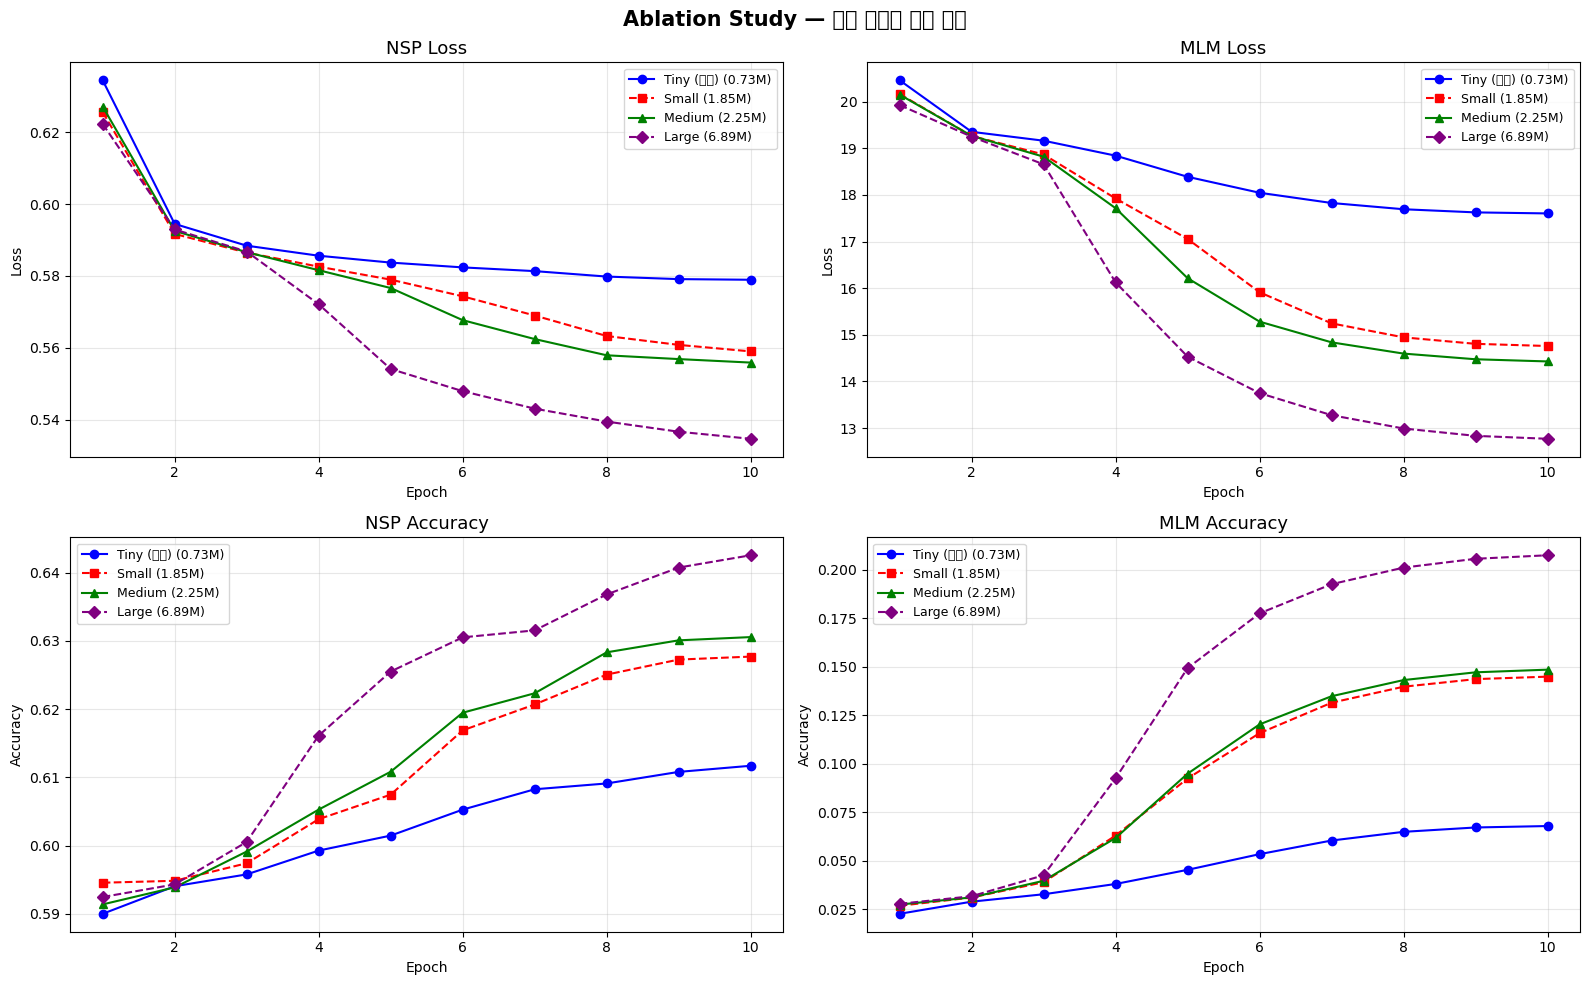


      실험            파라미터       NSP Loss     MLM Loss    NSP Acc    MLM Acc  
---------------------------------------------------------------------------
Tiny (현재)          725,120      0.5789     17.6047    0.6117    0.0679
Small            1,851,648      0.5590     14.7599    0.6277    0.1449
Medium           2,248,192      0.5559     14.4289    0.6306    0.1485
Large            6,888,448      0.5347     12.7690    0.6425    0.2074


In [27]:
# ── 결과 시각화 ──
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
styles = [('blue','o-'), ('red','s--'), ('green','^-'), ('purple','D--')]
x = range(1, EPOCHS + 1)

for (name, result), (color, ls) in zip(all_results.items(), styles):
    label = f"{name} ({result['params']/1e6:.2f}M)"
    axes[0,0].plot(x, result['nsp_loss'], ls, color=color, label=label)
    axes[0,1].plot(x, result['mlm_loss'], ls, color=color, label=label)
    axes[1,0].plot(x, result['nsp_acc'],  ls, color=color, label=label)
    axes[1,1].plot(x, result['mlm_acc'],  ls, color=color, label=label)

for ax, title, ylabel in zip(axes.flat,
    ['NSP Loss','MLM Loss','NSP Accuracy','MLM Accuracy'],
    ['Loss','Loss','Accuracy','Accuracy']):
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Ablation Study — 모델 크기별 성능 비교', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{work_dir}/ablation_study_result.png', dpi=150)
plt.show()

# ── 비교표 ──
print(f"\n{'='*75}")
print(f"{'실험':^15} {'파라미터':^12} {'NSP Loss':^12} {'MLM Loss':^12} {'NSP Acc':^10} {'MLM Acc':^10}")
print(f"{'-'*75}")
for name, result in all_results.items():
    print(f"{name:<15} {result['params']:>10,}  "
          f"{result['nsp_loss'][-1]:>10.4f}  {result['mlm_loss'][-1]:>10.4f}  "
          f"{result['nsp_acc'][-1]:>8.4f}  {result['mlm_acc'][-1]:>8.4f}")
print(f"{'='*75}")

In [28]:
# ── 4개 모델 동시 MLM 비교 ──
test_sentences = [
    ('대한민국의 수도는 [MASK]이다',      4),   # 정답: 서울
    ('그는 학교에서 [MASK]를 공부했다',   4),   # 정답: 수학 등
    ('하늘에서 [MASK]이 내린다',          3),   # 정답: 비/눈
    ('조선은 [MASK]년에 건국되었다',      3),   # 정답: 1392
]

for sentence, mask_pos in test_sentences:
    print(f'\n{"="*60}')
    print(f'문장: {sentence}')
    print(f'{"="*60}')

    for exp_cfg in experiment_configs:
        name = exp_cfg['name']

        # 모델 로드
        exp_config = Config({
            'd_model': exp_cfg['d_model'], 'n_head': exp_cfg['n_head'],
            'd_head': exp_cfg['d_head'], 'dropout': 0.1, 'd_ff': exp_cfg['d_ff'],
            'layernorm_epsilon': 1e-12, 'n_layer': exp_cfg['n_layer'],
            'n_seq': 128, 'n_vocab': len(vocab), 'i_pad': 0
        })
        model = build_model_pre_train(exp_config).to(device)
        save_name = name.replace(' ', '_').replace('(', '').replace(')', '')
        model.load_state_dict(torch.load(f'{work_dir}/ablation_{save_name}.pt', map_location=device))
        model.eval()

        # [MASK] 위치 예측
        tokens    = ['[CLS]'] + vocab.encode_as_pieces(sentence.replace('[MASK]', '[MASK]')) + ['[SEP]']
        token_ids = [vocab.piece_to_id(t) for t in tokens] + [0] * (128 - len(tokens))
        enc = torch.tensor([token_ids], dtype=torch.long).to(device)
        seg = torch.zeros_like(enc)

        with torch.no_grad():
            _, logits_lm = model(enc, seg)

        top5 = torch.topk(logits_lm[0, mask_pos], 5).indices.tolist()
        top5_tokens = [vocab.id_to_piece(i) for i in top5]

        print(f'  {name:<15} → {top5_tokens}')


문장: 대한민국의 수도는 [MASK]이다
  Tiny (현재)       → ['▁', ',', '▁이', '년', '의']
  Small           → ['▁', '하는', '▁중', '▁같은', '고']
  Medium          → ['▁', ',', '▁비', '(', '▁이']
  Large           → ['▁', '의', '▁가', '이', '▁수']

문장: 그는 학교에서 [MASK]를 공부했다
  Tiny (현재)       → ['▁', ',', '년', '의', '▁이']
  Small           → ['▁', '▁중', '하는', '▁같은', ',']
  Medium          → ['▁', '▁이', '▁비', '▁그', '▁"']
  Large           → ['▁', '▁가', '의', ',', '▁이']

문장: 하늘에서 [MASK]이 내린다
  Tiny (현재)       → ['에서', '리', '한', '와', '가']
  Small           → ['에서', '은', '는', '가', '년에']
  Medium          → ['에서', '▁전', '가', '은', '로']
  Large           → ['에서', '는', '▁이', '일', '를']

문장: 조선은 [MASK]년에 건국되었다
  Tiny (현재)       → ['▁', ',', '년', '의', '▁이']
  Small           → ['▁', '하는', '▁중', '▁같은', '고']
  Medium          → ['▁', '▁비', '(', '▁이', ',']
  Large           → ['▁', '▁가', ',', '▁이', '▁유']


In [29]:
test_sentences = [
    ('대한민국의 수도는 {} 이다',    '서울'),
    ('그는 학교에서 {} 를 공부했다', '수학'),
    ('하늘에서 {} 이 내린다',        '비'),
    ('조선은 {} 년에 건국되었다',    '1392'),
]

mask_token_id = vocab.piece_to_id('[MASK]')
print(f'[MASK] token id: {mask_token_id}')  # 6이어야 정상

for sentence_template, answer in test_sentences:
    before, after = sentence_template.split('{}')
    tokens_before = vocab.encode_as_pieces(before.strip())
    tokens_after  = vocab.encode_as_pieces(after.strip())

    # [CLS] + 앞부분 + [MASK] + 뒷부분 + [SEP] 직접 조립
    tokens    = ['[CLS]'] + tokens_before + ['[MASK]'] + tokens_after + ['[SEP]']
    mask_pos  = len(tokens_before) + 1  # [CLS] 다음부터니까 +1

    token_ids = [vocab.piece_to_id(t) for t in tokens]
    token_ids += [0] * (128 - len(token_ids))

    print(f'\n{"="*60}')
    print(f'문장: {sentence_template.replace("{}", "[MASK]")}  (정답: {answer})')
    print(f'토큰: {tokens}')
    print(f'MASK 위치: {mask_pos}')
    print(f'{"="*60}')

    for exp_cfg in experiment_configs:
        name = exp_cfg['name']
        exp_config = Config({
            'd_model': exp_cfg['d_model'], 'n_head': exp_cfg['n_head'],
            'd_head': exp_cfg['d_head'], 'dropout': 0.1, 'd_ff': exp_cfg['d_ff'],
            'layernorm_epsilon': 1e-12, 'n_layer': exp_cfg['n_layer'],
            'n_seq': 128, 'n_vocab': len(vocab), 'i_pad': 0
        })
        model = build_model_pre_train(exp_config).to(device)
        save_name = name.replace(' ', '_').replace('(', '').replace(')', '')
        model.load_state_dict(torch.load(f'{work_dir}/ablation_{save_name}.pt', map_location=device))
        model.eval()

        enc = torch.tensor([token_ids], dtype=torch.long).to(device)
        seg = torch.zeros_like(enc)

        with torch.no_grad():
            _, logits_lm = model(enc, seg)

        top5        = torch.topk(logits_lm[0, mask_pos], 5).indices.tolist()
        top5_tokens = [vocab.id_to_piece(i) for i in top5]
        correct     = '✅' if answer in ' '.join(top5_tokens) else '❌'
        print(f'  {correct} {name:<15} → {top5_tokens}')

[MASK] token id: 6

문장: 대한민국의 수도는 [MASK] 이다  (정답: 서울)
토큰: ['[CLS]', '▁대한민국의', '▁수도', '는', '[MASK]', '▁이', '다', '[SEP]']
MASK 위치: 4
  ❌ Tiny (현재)       → ['.', '▁위치한', ',', '이다', '▁있는']
  ❌ Small           → ['▁다음을', '▁뜻은', '▁가리키는', '▁사람을', '▁뜻이']
  ❌ Medium          → ['▁다음을', '▁다른', '▁다음과', '▁다음', '▁뜻은']
  ❌ Large           → ['▁대한민국의', '▁일본의', '▁일본', '▁러시아', '▁대한민국']

문장: 그는 학교에서 [MASK] 를 공부했다  (정답: 수학)
토큰: ['[CLS]', '▁그는', '▁학교', '에서', '[MASK]', '▁', '를', '▁공부', '했다', '[SEP]']
MASK 위치: 4
  ❌ Tiny (현재)       → ['.', ',', '의', '년', '에']
  ❌ Small           → ['▁다른', '▁같은', '▁다음', '▁사람을', '▁다음을']
  ❌ Medium          → ['▁다른', '▁같은', '▁뜻은', '▁다음', '▁사람을']
  ❌ Large           → ['▁일본', '▁일본의', '▁대한민국의', '▁다음', '▁한']

문장: 하늘에서 [MASK] 이 내린다  (정답: 비)
토큰: ['[CLS]', '▁하', '늘', '에서', '[MASK]', '▁이', '▁내', '린다', '[SEP]']
MASK 위치: 4
  ❌ Tiny (현재)       → ['.', '이다', '▁있다', ',', '의']
  ❌ Small           → ['▁다른', '▁뜻은', '▁다음을', '▁가리키는', '▁같은']
  ❌ Medium          → ['▁다른', '▁뜻은', '▁같은', '▁가리키는', 